# HW14 - Эмбеддинги, FAISS, оценка retrieval и mini-RAG

Реализован полный учебный pipeline: база знаний -> чанкинг -> векторизация -> FAISS -> оценка retrieval -> обновление базы знаний -> mini-RAG.

In [1]:
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import faiss

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
print('DATA_DIR exists:', DATA_DIR.exists())
print('faiss version:', faiss.__version__)
print('seed:', SEED)

PROJECT_DIR: C:\ucheba\ai\Damir\homeworks\HW14
DATA_DIR exists: True
faiss version: 1.13.2
seed: 42


## 1. База знаний и первичный анализ

Предметная область: практические заметки по ML/MLOps и базовому RAG.

In [2]:
with (DATA_DIR / 'base_documents.json').open('r', encoding='utf-8') as f:
    base_documents = json.load(f)

kb_df = pd.DataFrame(base_documents)
print('Число документов в исходной базе:', len(kb_df))
kb_df[['doc_id', 'title']]

Число документов в исходной базе: 12


,doc_id,title
0,pandas_joins,"Pandas: merge, join и concat"
1,sklearn_cv,Кросс-валидация и подбор гиперпараметров
2,ml_metrics,Метрики качества при дисбалансе классов
3,regularization,Борьба с переобучением
4,ml_docker,Docker для ML-сервисов
5,feature_store,Feature Store: offline и online слой
6,ab_testing,A/B-тестирование продуктовых ML-фич
7,model_monitoring,Мониторинг модели после релиза
8,faiss_intro,FAISS и векторный поиск
9,data_leakage,Data leakage в ML-пайплайне


In [3]:
print('Примеры 5 документов:')
for row in kb_df.head(5).itertuples(index=False):
    print('-', row.doc_id, '->', row.text[:220].replace('\n', ' '), '...')

Примеры 5 документов:
- pandas_joins -> Pandas поддерживает несколько способов объединения таблиц: merge, join и concat. merge используется, когда нужно соединить DataFrame по ключам, как SQL JOIN. join удобен для объединения по индексу, а concat полезен для с ...
- sklearn_cv -> Кросс-валидация оценивает устойчивость модели и снижает риск случайно завышенной метрики на одном split. На практике часто используют KFold или StratifiedKFold, если задача классификации и нужно сохранить доли классов в  ...
- ml_metrics -> При дисбалансе классов accuracy может быть обманчивой: модель предсказывает доминирующий класс и получает высокий скор, не находя редкие события. Поэтому чаще смотрят precision, recall и F1, особенно для целевого редкого ...
- regularization -> Переобучение возникает, когда модель слишком точно запоминает шум тренировочных данных и хуже обобщает на новых примерах. Часто это видно по большому разрыву между train-метрикой и validation-метрикой.  Базовые способы б ...
- ml_doc

## 2. Чанкинг документов

In [4]:
def chunk_text_by_words(text, chunk_size=85, overlap=20):
    words = text.split()
    if len(words) <= chunk_size:
        return [' '.join(words)]
    step = max(1, chunk_size - overlap)
    chunks = []
    for start in range(0, len(words), step):
        end = start + chunk_size
        part = words[start:end]
        if not part:
            break
        chunks.append(' '.join(part))
        if end >= len(words):
            break
    return chunks

def build_chunks(documents, chunk_size=85, overlap=20):
    rows = []
    for doc in documents:
        chunks = chunk_text_by_words(doc['text'], chunk_size=chunk_size, overlap=overlap)
        for i, chunk in enumerate(chunks):
            rows.append({
                'chunk_id': f"{doc['doc_id']}_chunk_{i}",
                'doc_id': doc['doc_id'],
                'title': doc['title'],
                'chunk_text': chunk,
                'chunk_len_words': len(chunk.split())
            })
    return pd.DataFrame(rows)

CHUNK_SIZE = 45
CHUNK_OVERLAP = 12
chunks_df = build_chunks(base_documents, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
print('Всего чанков:', len(chunks_df))
print('Средняя длина чанка (слов):', round(chunks_df['chunk_len_words'].mean(), 2))
chunks_df.head(10)

Всего чанков: 31
Средняя длина чанка (слов): 38.87


,chunk_id,doc_id,title,chunk_text,chunk_len_words
0,pandas_joins_chunk_0,pandas_joins,"Pandas: merge, join и concat",Pandas поддерживает несколько способов объедин...,45
1,pandas_joins_chunk_1,pandas_joins,"Pandas: merge, join и concat",строкам или столбцам. При merge важно явно ука...,45
2,pandas_joins_chunk_2,pandas_joins,"Pandas: merge, join и concat","из справочника. Если ключи не уникальны, merge...",45
3,pandas_joins_chunk_3,pandas_joins,"Pandas: merge, join и concat",проверить пропуски. Это снижает риск тихих оши...,20
4,sklearn_cv_chunk_0,sklearn_cv,Кросс-валидация и подбор гиперпараметров,Кросс-валидация оценивает устойчивость модели ...,45
5,sklearn_cv_chunk_1,sklearn_cv,Кросс-валидация и подбор гиперпараметров,"гиперпараметры, важно не смотреть на тест зара...",45
6,sklearn_cv_chunk_2,sklearn_cv,Кросс-валидация и подбор гиперпараметров,"мало, кросс-валидация особенно полезна: она по...",26
7,ml_metrics_chunk_0,ml_metrics,Метрики качества при дисбалансе классов,При дисбалансе классов accuracy может быть обм...,45
8,ml_metrics_chunk_1,ml_metrics,Метрики качества при дисбалансе классов,ранжирования вероятностей полезны ROC-AUC и PR...,45
9,ml_metrics_chunk_2,ml_metrics,Метрики качества при дисбалансе классов,"метрику из бизнес-рисков: где дороже ошибка, п...",21


In [5]:
example_doc = 'faiss_intro'
ex = chunks_df[chunks_df['doc_id'] == example_doc]
print(f'Документ {example_doc} -> {len(ex)} чанков')
for row in ex.itertuples(index=False):
    print(row.chunk_id, ':', row.chunk_text[:220], '...')

Документ faiss_intro -> 2 чанков
faiss_intro_chunk_0 : FAISS - библиотека для быстрого поиска ближайших векторов. В учебных задачах часто используют IndexFlatIP или IndexFlatL2, где поиск точный и простой для понимания. Для больших коллекций применяют приближенные индексы (н ...
faiss_intro_chunk_1 : чтобы ускорить поиск и уменьшить память. Обычно перед IndexFlatIP векторы L2-нормируют, тогда скалярное произведение приближает cosine similarity. В RAG-сценариях FAISS хранит эмбеддинги чанков документов, а на запросе в ...


## 3. Векторизация и индекс FAISS

In [6]:
def build_retriever(chunks):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    matrix = vectorizer.fit_transform(chunks['chunk_text']).astype(np.float32)
    dense = matrix.toarray().astype(np.float32)
    dense = normalize(dense, norm='l2', copy=False).astype(np.float32)
    index = faiss.IndexFlatIP(dense.shape[1])
    index.add(dense)
    return {'chunks': chunks.reset_index(drop=True), 'vectorizer': vectorizer, 'index': index, 'embeddings': dense}

def retrieve(query, retriever, top_k=4):
    q = retriever['vectorizer'].transform([query]).astype(np.float32).toarray()
    q = normalize(q, norm='l2', copy=False).astype(np.float32)
    k = min(top_k, len(retriever['chunks']))
    scores, indices = retriever['index'].search(q, k)
    out = retriever['chunks'].iloc[indices[0]].copy().reset_index(drop=True)
    out['score'] = scores[0]
    out['rank'] = np.arange(1, len(out) + 1)
    return out

retriever = build_retriever(chunks_df)
print('Размерность векторов:', retriever['embeddings'].shape[1])
print('Векторов в индексе:', retriever['index'].ntotal)

Размерность векторов: 1509
Векторов в индексе: 31


In [7]:
sample_queries = [
    'Как в pandas объединять таблицы по ключам?',
    'Для чего используют PR-AUC при дисбалансе классов?',
    'Как бороться с переобучением модели?',
    'Зачем нужен feature store в ML-платформе?',
    'Когда применять FAISS в RAG?'
]

for q in sample_queries:
    print('=' * 90)
    print('Запрос:', q)
    display(retrieve(q, retriever, top_k=3)[['rank', 'doc_id', 'title', 'score']])

Запрос: Как в pandas объединять таблицы по ключам?


,rank,doc_id,title,score
0,1,pandas_joins,"Pandas: merge, join и concat",0.240304
1,2,pandas_joins,"Pandas: merge, join и concat",0.042352
2,3,pandas_joins,"Pandas: merge, join и concat",0.041026


Запрос: Для чего используют PR-AUC при дисбалансе классов?


,rank,doc_id,title,score
0,1,ml_metrics,Метрики качества при дисбалансе классов,0.401049
1,2,ml_metrics,Метрики качества при дисбалансе классов,0.236112
2,3,sklearn_cv,Кросс-валидация и подбор гиперпараметров,0.068285


Запрос: Как бороться с переобучением модели?


,rank,doc_id,title,score
0,1,pandas_joins,"Pandas: merge, join и concat",0.087598
1,2,ml_docker,Docker для ML-сервисов,0.073306
2,3,ml_metrics,Метрики качества при дисбалансе классов,0.065288


Запрос: Зачем нужен feature store в ML-платформе?


,rank,doc_id,title,score
0,1,feature_store,Feature Store: offline и online слой,0.344210
1,2,ml_docker,Docker для ML-сервисов,0.047156
2,3,ab_testing,A/B-тестирование продуктовых ML-фич,0.045624


Запрос: Когда применять FAISS в RAG?


,rank,doc_id,title,score
0,1,faiss_intro,FAISS и векторный поиск,0.138186
1,2,faiss_intro,FAISS и векторный поиск,0.068615
2,3,grounded_answers,Grounded-ответы и ссылки на источники,0.055620


## 4. Контрольные запросы и оценка retrieval

In [8]:
control_queries = [
    {'query': 'Как в pandas объединить две таблицы по user_id и сохранить все строки из левой таблицы?', 'expected_sources': ['pandas_joins']},
    {'query': 'Зачем нужна кросс-валидация при подборе гиперпараметров модели?', 'expected_sources': ['sklearn_cv']},
    {'query': 'Почему accuracy плохо подходит при сильном дисбалансе классов?', 'expected_sources': ['ml_metrics']},
    {'query': 'Какие методы помогают уменьшить переобучение?', 'expected_sources': ['regularization']},
    {'query': 'Что дает Docker в ML-проекте и деплое?', 'expected_sources': ['ml_docker']},
    {'query': 'Зачем нужен feature store и как он связан с training-serving skew?', 'expected_sources': ['feature_store']},
    {'query': 'Как корректно организовать A/B-тест для ML-рекомендателя?', 'expected_sources': ['ab_testing']},
    {'query': 'Что мониторить у модели после релиза, чтобы не пропустить деградацию?', 'expected_sources': ['model_monitoring', 'ml_metrics']},
    {'query': 'Когда в RAG используют FAISS и зачем нормировать векторы?', 'expected_sources': ['faiss_intro', 'rag_context']},
    {'query': 'Что такое data leakage и почему он опасен для offline-метрик?', 'expected_sources': ['data_leakage']},
]

TOP_K = 3

In [9]:
def evaluate_retrieval(control_data, retriever, top_k=3):
    rows = []
    for item in control_data:
        query = item['query']
        expected = list(item['expected_sources'])
        expected_set = set(expected)
        hits_df = retrieve(query, retriever, top_k=top_k)
        retrieved_sources = list(dict.fromkeys(hits_df['doc_id'].tolist()))
        inter = [s for s in retrieved_sources if s in expected_set]
        hit = int(len(inter) > 0)
        recall = len(inter) / max(1, len(expected_set))
        rank = np.nan
        for i, src in enumerate(retrieved_sources, start=1):
            if src in expected_set:
                rank = i
                break
        rows.append({
            'query': query,
            'expected_source': '|'.join(expected),
            'retrieved_sources': '|'.join(retrieved_sources),
            'hit_at_k': hit,
            'recall_at_k': recall,
            'rank_of_first_relevant': rank
        })
    eval_df = pd.DataFrame(rows)
    mrr = np.mean([0.0 if pd.isna(r) else 1.0 / r for r in eval_df['rank_of_first_relevant']])
    summary = {
        'hit_at_k': float(eval_df['hit_at_k'].mean()),
        'recall_at_k': float(eval_df['recall_at_k'].mean()),
        'mrr_at_k': float(mrr),
        'num_queries': int(len(eval_df)),
        'k': int(top_k),
    }
    return eval_df, summary

retrieval_eval_df, retrieval_summary = evaluate_retrieval(control_queries, retriever, top_k=TOP_K)
retrieval_eval_df.to_csv(ARTIFACTS_DIR / 'retrieval_eval.csv', index=False)
print(json.dumps(retrieval_summary, indent=2, ensure_ascii=False))
retrieval_eval_df

{
  "hit_at_k": 1.0,
  "recall_at_k": 0.95,
  "mrr_at_k": 0.9333333333333332,
  "num_queries": 10,
  "k": 3
}


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,Как в pandas объединить две таблицы по user_id...,pandas_joins,pandas_joins,1,1.0,1
1,Зачем нужна кросс-валидация при подборе гиперп...,sklearn_cv,sklearn_cv,1,1.0,1
2,Почему accuracy плохо подходит при сильном дис...,ml_metrics,ml_metrics|sklearn_cv|pandas_joins,1,1.0,1
3,Какие методы помогают уменьшить переобучение?,regularization,regularization|faiss_intro|grounded_answers,1,1.0,1
4,Что дает Docker в ML-проекте и деплое?,ml_docker,ml_docker|ab_testing|ml_metrics,1,1.0,1
5,Зачем нужен feature store и как он связан с tr...,feature_store,feature_store|pandas_joins,1,1.0,1
6,Как корректно организовать A/B-тест для ML-рек...,ab_testing,ml_docker|sklearn_cv|ab_testing,1,1.0,3
7,"Что мониторить у модели после релиза, чтобы не...",model_monitoring|ml_metrics,model_monitoring|data_leakage|ml_metrics,1,1.0,1
8,Когда в RAG используют FAISS и зачем нормирова...,faiss_intro|rag_context,faiss_intro|sklearn_cv,1,0.5,1
9,Что такое data leakage и почему он опасен для ...,data_leakage,data_leakage|ml_docker|regularization,1,1.0,1


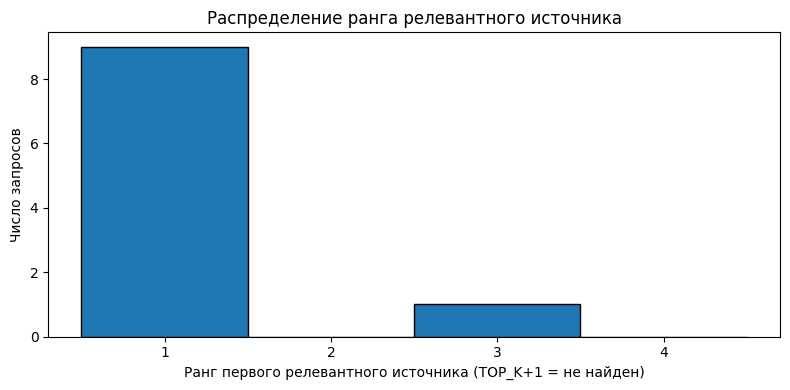

In [10]:
plt.figure(figsize=(8, 4))
plot_df = retrieval_eval_df.copy()
plot_df['rank_for_plot'] = plot_df['rank_of_first_relevant'].fillna(TOP_K + 1)
plot_df['rank_for_plot'].plot(kind='hist', bins=np.arange(1, TOP_K + 3) - 0.5, edgecolor='black')
plt.xticks(range(1, TOP_K + 2))
plt.xlabel('Ранг первого релевантного источника (TOP_K+1 = не найден)')
plt.ylabel('Число запросов')
plt.title('Распределение ранга релевантного источника')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'retrieval_quality_plot.png', dpi=140)
plt.show()

## 5. Эксперимент: сравнение chunk_size

In [11]:
def run_pipeline(documents, chunk_size, overlap, control_data, top_k):
    local_chunks = build_chunks(documents, chunk_size=chunk_size, overlap=overlap)
    local_retriever = build_retriever(local_chunks)
    _, summary = evaluate_retrieval(control_data, local_retriever, top_k=top_k)
    return summary

variants = [
    {'variant': 'narrow_chunks', 'chunk_size': 40, 'overlap': 10},
    {'variant': 'balanced_chunks', 'chunk_size': 45, 'overlap': 12},
]

rows = []
for v in variants:
    summary = run_pipeline(base_documents, v['chunk_size'], v['overlap'], control_queries, TOP_K)
    rows.append({**v, **summary})

experiment_df = pd.DataFrame(rows).sort_values(by=['hit_at_k', 'recall_at_k', 'mrr_at_k'], ascending=False).reset_index(drop=True)
experiment_df

,variant,chunk_size,overlap,hit_at_k,recall_at_k,mrr_at_k,num_queries,k
0,balanced_chunks,45,12,1.0,0.95,0.933333,10,3
1,narrow_chunks,40,10,0.9,0.80,0.850000,10,3


In [12]:
best_variant = experiment_df.iloc[0].to_dict()
CHUNK_SIZE = int(best_variant['chunk_size'])
CHUNK_OVERLAP = int(best_variant['overlap'])
print('Выбранный вариант:', best_variant)

chunks_df = build_chunks(base_documents, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
retriever = build_retriever(chunks_df)
retrieval_eval_df, retrieval_summary = evaluate_retrieval(control_queries, retriever, top_k=TOP_K)
retrieval_eval_df.to_csv(ARTIFACTS_DIR / 'retrieval_eval.csv', index=False)
print('Итоговая метрика hit@k:', retrieval_summary['hit_at_k'])
print('Итоговая метрика recall@k:', retrieval_summary['recall_at_k'])
print('Итоговая метрика mrr@k:', retrieval_summary['mrr_at_k'])

Выбранный вариант: {'variant': 'balanced_chunks', 'chunk_size': 45, 'overlap': 12, 'hit_at_k': 1.0, 'recall_at_k': 0.95, 'mrr_at_k': 0.9333333333333332, 'num_queries': 10, 'k': 3}
Итоговая метрика hit@k: 1.0
Итоговая метрика recall@k: 0.95
Итоговая метрика mrr@k: 0.9333333333333332


## 6. Обновление базы знаний и переиндексация

In [13]:
with (DATA_DIR / 'new_documents.json').open('r', encoding='utf-8') as f:
    new_documents = json.load(f)

updated_documents = base_documents + new_documents
print('Было документов:', len(base_documents))
print('Стало документов:', len(updated_documents))

Было документов: 12
Стало документов: 15


In [14]:
before_retriever = retriever
updated_chunks_df = build_chunks(updated_documents, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
after_retriever = build_retriever(updated_chunks_df)

update_queries = [
    'Что такое guardrails в LLM-приложениях и где их ставят?',
    'Когда в проде лучше использовать pgvector, а не FAISS?',
    'Как отслеживать concept drift после релиза модели?',
    'Как бороться с training-serving skew в продакшене?',
    'Почему при дисбалансе классов PR-AUC часто полезнее accuracy?',
]

comparison_rows = []
for q in update_queries:
    before_sources = list(dict.fromkeys(retrieve(q, before_retriever, top_k=3)['doc_id'].tolist()))
    after_sources = list(dict.fromkeys(retrieve(q, after_retriever, top_k=3)['doc_id'].tolist()))
    comparison_rows.append({
        'query': q,
        'before_retrieved_sources': '|'.join(before_sources),
        'after_retrieved_sources': '|'.join(after_sources),
        'changed': before_sources != after_sources
    })

before_after_df = pd.DataFrame(comparison_rows)
before_after_df.to_csv(ARTIFACTS_DIR / 'retrieval_before_after_update.csv', index=False)
before_after_df

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Что такое guardrails в LLM-приложениях и где и...,ml_metrics|ml_docker,llm_guardrails|ml_metrics,True
1,"Когда в проде лучше использовать pgvector, а н...",grounded_answers|ml_docker,vector_db_pgvector|grounded_answers,True
2,Как отслеживать concept drift после релиза мод...,data_leakage|model_monitoring|feature_store,concept_drift|data_leakage|model_monitoring,True
3,Как бороться с training-serving skew в продакш...,feature_store|regularization|pandas_joins,feature_store|concept_drift|regularization,True
4,Почему при дисбалансе классов PR-AUC часто пол...,ml_metrics|sklearn_cv,ml_metrics|llm_guardrails,True


## 7. Mini-RAG

In [15]:
RU_STOPWORDS = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да',
    'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о',
    'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до',
    'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где',
    'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже'
}

def tokenize_ru(text):
    tokens = re.findall(r'[a-zA-Zа-яА-Я0-9\-]+', text.lower())
    return [t for t in tokens if t not in RU_STOPWORDS and len(t) > 2]

def extractive_answer(question, retrieved_df, max_sentences=2):
    q_tokens = set(tokenize_ru(question))
    candidates = []
    for row in retrieved_df.itertuples(index=False):
        sentences = re.split(r'(?<=[.!?])\s+', row.chunk_text)
        for sent in sentences:
            sent = sent.strip()
            if len(sent) < 35:
                continue
            s_tokens = set(tokenize_ru(sent))
            overlap = len(q_tokens & s_tokens)
            candidates.append((overlap, sent, row.doc_id))
    candidates.sort(key=lambda x: x[0], reverse=True)
    selected = []
    seen = set()
    best = 0
    for score, sent, src in candidates:
        if sent in seen:
            continue
        seen.add(sent)
        best = max(best, score)
        selected.append((sent, src))
        if len(selected) >= max_sentences:
            break
    if not selected or best == 0:
        return 'В текущем контексте недостаточно точной информации для уверенного ответа. Нужны дополнительные документы или более конкретный вопрос.'
    return ' '.join([s for s, _ in selected])

def mini_rag(question, retriever, top_k=4):
    retrieved = retrieve(question, retriever, top_k=top_k)
    answer = extractive_answer(question, retrieved, max_sentences=2)
    sources = list(dict.fromkeys(retrieved['doc_id'].tolist()))
    return {'question': question, 'answer': answer, 'retrieved_sources': sources}

rag_questions = [
    'Как уменьшить переобучение модели в production?',
    'Почему feature store важен для согласованности train и serving?',
    'Как guardrails делают LLM-приложение безопаснее?',
    'Какая стратегия лучше для мультиязычного retrieval в RAG?',
    'Сколько инженеров нужно для зрелой MLOps-команды?',
]

rag_rows = []
for q in rag_questions:
    result = mini_rag(q, after_retriever, top_k=4)
    rag_rows.append({
        'question': result['question'],
        'answer': result['answer'],
        'retrieved_sources': '|'.join(result['retrieved_sources'])
    })

rag_examples_df = pd.DataFrame(rag_rows)
rag_examples_df.to_csv(ARTIFACTS_DIR / 'rag_examples.csv', index=False)
rag_examples_df

,question,answer,retrieved_sources
0,Как уменьшить переобучение модели в production?,В production важно иметь план реакции: кто и к...,concept_drift|regularization|ml_docker
1,Почему feature store важен для согласованности...,Главная ценность feature store - консистентнос...,feature_store|llm_guardrails
2,Как guardrails делают LLM-приложение безопаснее?,"Guardrails - это набор ограничений и проверок,...",llm_guardrails|concept_drift
3,Какая стратегия лучше для мультиязычного retri...,В RAG guardrails часто ставят на нескольких эт...,grounded_answers|rag_context|llm_guardrails
4,Сколько инженеров нужно для зрелой MLOps-команды?,"pgvector полезен, когда векторный поиск нужно ...",vector_db_pgvector|pandas_joins|model_monitori...


In [16]:
print('Примеры mini-RAG:')
for row in rag_examples_df.itertuples(index=False):
    print('-' * 100)
    print('Вопрос:', row.question)
    print('Ответ:', row.answer)
    print('Источники:', row.retrieved_sources)

error_analysis = pd.DataFrame([
    {'case': 'Мультиязычный retrieval', 'what_went_wrong': 'В базе нет документов про мультиязычные эмбеддинги и cross-lingual retrieval, поэтому ответ частично нерелевантен.'},
    {'case': 'Планирование команды', 'what_went_wrong': 'В базе знаний нет данных про размер MLOps-команды, mini-RAG корректно сигнализирует о нехватке контекста.'},
    {'case': 'Смежные темы drift/leakage', 'what_went_wrong': 'Часть запросов может подтягивать близкие темы и приносить в контекст шумные фрагменты.'},
])
error_analysis

Примеры mini-RAG:
----------------------------------------------------------------------------------------------------
Вопрос: Как уменьшить переобучение модели в production?
Ответ: В production важно иметь план реакции: кто и как запускает retraining, какие пороги считаются критическими и как откатывать Переобучение возникает, когда модель слишком точно запоминает шум тренировочных данных и хуже обобщает на новых примерах.
Источники: concept_drift|regularization|ml_docker
----------------------------------------------------------------------------------------------------
Вопрос: Почему feature store важен для согласованности train и serving?
Ответ: Главная ценность feature store - консистентность признаков между train и serving. Feature store хранит и переиспользует признаки для обучения и онлайн-инференса.
Источники: feature_store|llm_guardrails
----------------------------------------------------------------------------------------------------
Вопрос: Как guardrails делают LLM-прило

,case,what_went_wrong
0,Мультиязычный retrieval,В базе нет документов про мультиязычные эмбедд...
1,Планирование команды,В базе знаний нет данных про размер MLOps-кома...
2,Смежные темы drift/leakage,Часть запросов может подтягивать близкие темы ...


In [17]:
metrics_summary = {
    'k': TOP_K,
    'num_control_queries': len(control_queries),
    'num_docs_before_update': len(base_documents),
    'num_docs_after_update': len(updated_documents),
    'num_chunks_before_update': len(chunks_df),
    'num_chunks_after_update': len(updated_chunks_df),
    **retrieval_summary,
}

with (ARTIFACTS_DIR / 'retrieval_metrics_summary.json').open('w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

print('Сохранены обязательные артефакты:')
for name in ['retrieval_eval.csv', 'rag_examples.csv', 'retrieval_before_after_update.csv']:
    p = ARTIFACTS_DIR / name
    print('-', p, 'exists=', p.exists())

print('Дополнительно:')
print('-', ARTIFACTS_DIR / 'retrieval_metrics_summary.json')
print('-', ARTIFACTS_DIR / 'retrieval_quality_plot.png')
print('Итоговые метрики retrieval:', retrieval_summary)

Сохранены обязательные артефакты:
- C:\ucheba\ai\Damir\homeworks\HW14\artifacts\retrieval_eval.csv exists= True
- C:\ucheba\ai\Damir\homeworks\HW14\artifacts\rag_examples.csv exists= True
- C:\ucheba\ai\Damir\homeworks\HW14\artifacts\retrieval_before_after_update.csv exists= True
Дополнительно:
- C:\ucheba\ai\Damir\homeworks\HW14\artifacts\retrieval_metrics_summary.json
- C:\ucheba\ai\Damir\homeworks\HW14\artifacts\retrieval_quality_plot.png
Итоговые метрики retrieval: {'hit_at_k': 1.0, 'recall_at_k': 0.95, 'mrr_at_k': 0.9333333333333332, 'num_queries': 10, 'k': 3}
